In [ ]:
import pandas as pd
#link= 'https://drive.google.com/file/d/1Dn0flBhhuC1XnAnlbSfWMaqsYTqJxrvo/view'
#path = 'https://drive.google.com/uc?export=download&id=' + link.split('/')[-2]
#df = pd.read_csv(path)
df = pd.read_csv('alzheimers_disease_data.csv')
import matplotlib.pyplot as plt #Thư viện cho vẽ hình
import seaborn as sns; sns.set()
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120}) #Cài đặt kích thước cho toàn bộ các hình trong file notebook này giống nhau
df.head(5)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [ ]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [ ]:
#Xóa bớt các cột ko cần thiết:
df = df.drop(['PatientID','DoctorInCharge'], axis=1)

In [ ]:
df.tail(5)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
2144,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,...,0.238667,0,0,4.492838,1,0,0,0,0,1
2145,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,...,8.687480,0,1,9.204952,0,0,0,0,0,1
2146,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,...,1.972137,0,0,5.036334,0,0,0,0,0,1
2147,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,...,5.173891,0,0,3.785399,0,0,0,0,1,1
2148,72,0,0,2,33.289738,0,7.890703,6.570993,7.941404,9.878711,...,6.307543,0,1,8.327563,0,1,0,0,1,0


EDA (sample)

In [ ]:
df['Diagnosis'].value_counts()

,count
Diagnosis,
0,1389
1,760


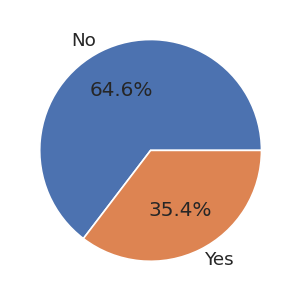

In [ ]:
#  #Phần trăm mắc bệnh
# import matplotlib.pyplot as plt
# plt.pie(df['Diagnosis'].value_counts(), autopct='%1.1f%%', labels=['No', 'Yes'])
# plt.show()

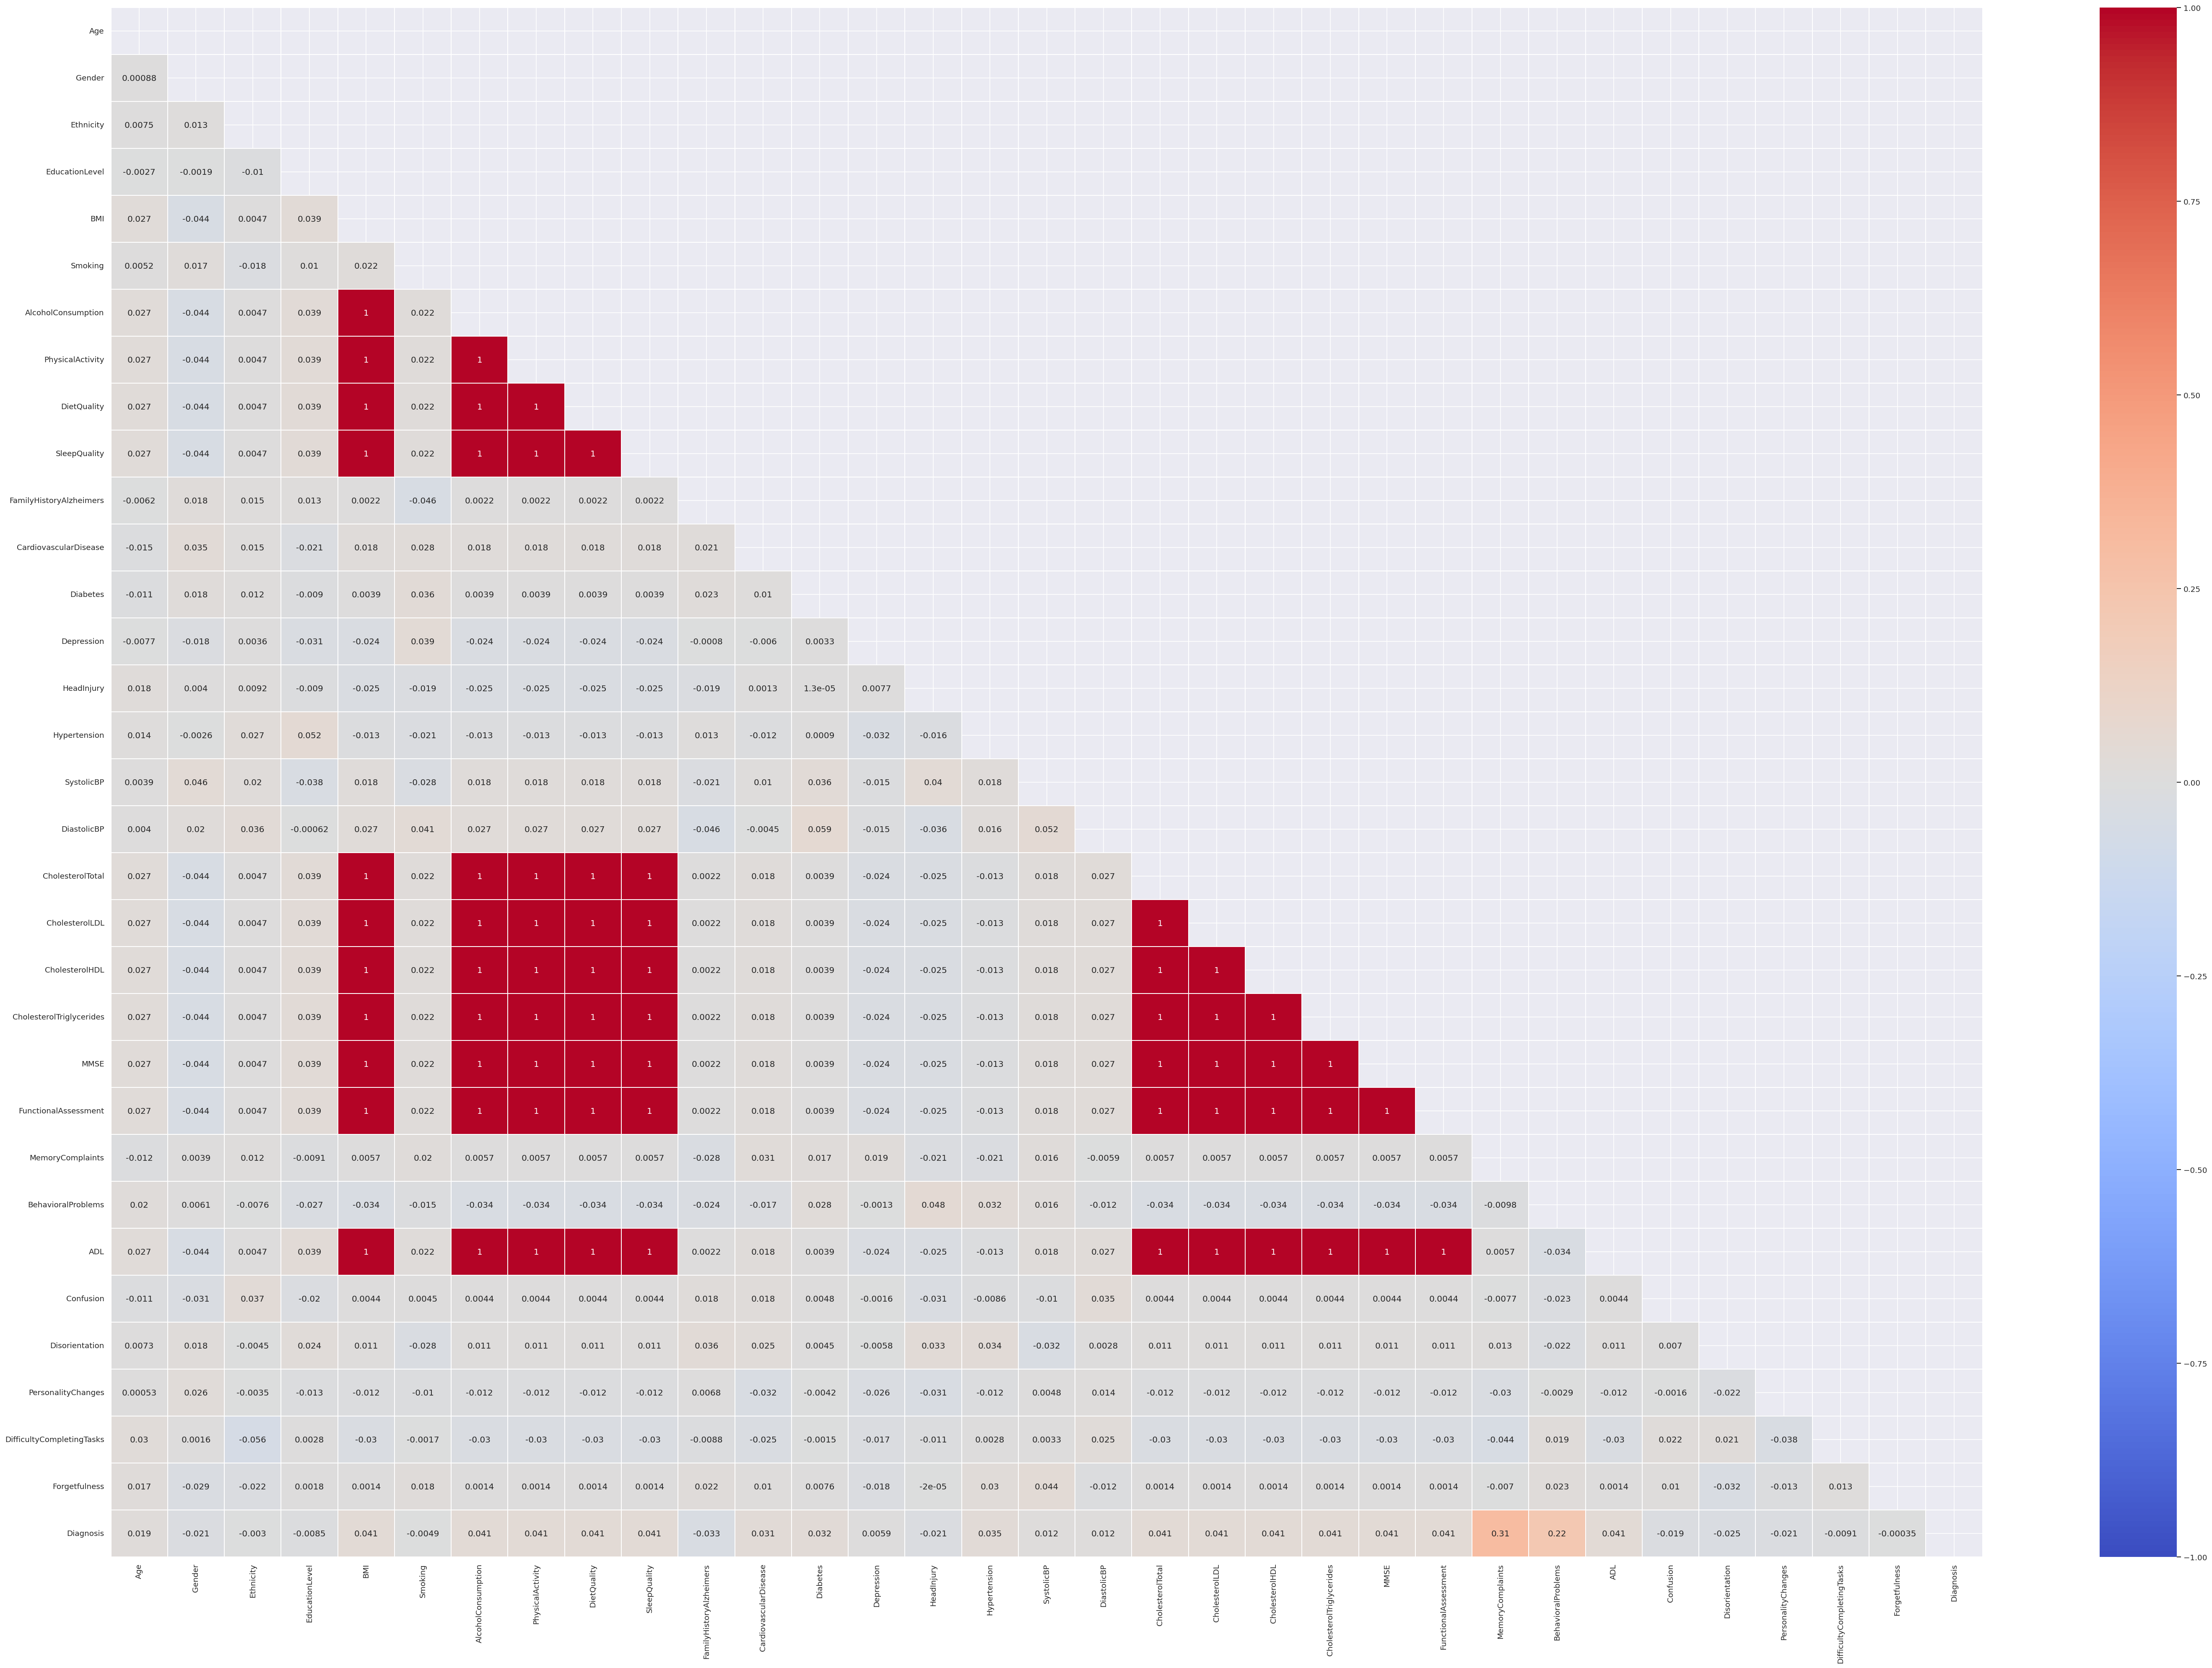

In [ ]:
# #Corr
# import numpy as np
# import seaborn as sns
# plt.figure(figsize=(60, 40))
# corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
# ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

In [ ]:
# #Alzheimer by age
# import seaborn as sns
# plt.rcParams.update({'figure.figsize':(4,3), 'figure.dpi':120})
# sns.boxplot(x = df.Diagnosis, y = df.Age)
# plt.title('Alzheimer by age')

In [ ]:
df_1 = df[['Diagnosis', 'Gender']].value_counts().reset_index()
df_1

,Diagnosis,Gender,count
0,0,1,714
1,0,0,675
2,1,0,386
3,1,1,374


In [ ]:
# #Alzheimer by gender
# plt.figure(figsize=(7,8))
# sns.barplot(data=df_1 , x=df_1['Diagnosis'], y=df_1['count'], hue=df_1['Gender'])
# plt.title('Number of Alzheimer patients by gender')
# plt.xlabel('# of patients by gender')
# plt.ylabel('Number')
# x = ['No', 'Yes']
# plt.show()

In [ ]:
df_2 = df[['Diagnosis', 'Ethnicity']].value_counts().reset_index()
df_2

,Diagnosis,Ethnicity,count
0,0,0,815
1,1,0,463
2,0,1,308
3,1,1,146
4,0,3,144
5,0,2,122
6,1,2,84
7,1,3,67


In [ ]:
# #Alzheimer by Ethnicity
# plt.figure(figsize=(7,8))
# sns.barplot(data=df_2 , x=df_2['Diagnosis'], y=df_2['count'], hue=df_2['Ethnicity'])
# plt.title('Number of Alzheimer by Ethnicity')
# plt.xlabel('# of patients by Ethnicity')
# x = ['No', 'Yes']
# plt.show()

In [ ]:
df_3 = df[['Diagnosis', 'Smoking']].value_counts().reset_index()
df_3

,Diagnosis,Smoking,count
0,0,0,986
1,1,0,543
2,0,1,403
3,1,1,217


In [ ]:
# #Alzheimer by Smoking
# plt.figure(figsize=(7,8))
# sns.barplot(data=df_3 , x=df_3['Diagnosis'], y=df_3['count'], hue=df_3['Smoking'])
# plt.title('Number of Alzheimer patients by smoking')
# plt.xlabel('# of patients')
# plt.ylabel('Smoking status')
# x = ['No', 'Yes']
# plt.show()

In [ ]:
df_4 = df[['Diagnosis', 'HeadInjury']].value_counts().reset_index()
df_4

,Diagnosis,HeadInjury,count
0,0,0,1254
1,1,0,696
2,0,1,135
3,1,1,64


In [ ]:
# # Alzheimer by HeadInjury
# plt.figure(figsize=(7,8))
# sns.barplot(data=df_4 , x=df_4['Diagnosis'], y=df_4['count'], hue=df_4['HeadInjury'])
# plt.title('Number of patients by HeadInjury')
# plt.xlabel('# of patients')
# plt.ylabel('Head Injury status')
# x = ['No', 'Yes']
# plt.show()

In [ ]:
#Mã hoá data cho bước xây dựng mô hình
#Chọn data object để mã hóa
selected_columns = df.select_dtypes(include=['object'])
#Mã hóa bằng LabelEncoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in selected_columns.columns:
    df[column] = label_encoder.fit_transform(df[column])

In [ ]:
#Data
y=df['Diagnosis']
X=df.drop('Diagnosis',axis='columns',inplace=False)
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0) # Chia dữ liệu với 30% số lượng là tets và 70% số lượng là training

In [ ]:
#scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,21.463532,6.518877,0,0,1.725883,0,0,0,1,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,20.613267,7.118696,0,0,2.592424,0,0,0,0,1
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,7.356249,5.895077,0,0,7.119548,0,1,0,1,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,13.991127,8.965106,0,1,6.481226,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,13.517609,6.045039,0,0,0.014691,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,...,1.201190,0.238667,0,0,4.492838,1,0,0,0,0
2145,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,...,6.458060,8.687480,0,1,9.204952,0,0,0,0,0
2146,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,...,17.011003,1.972137,0,0,5.036334,0,0,0,0,0
2147,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,...,4.030491,5.173891,0,0,3.785399,0,0,0,0,1


In [ ]:
df.head(3)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0


**Logistic Regression**

>



In [ ]:
dum=X.columns.values
Name=[]
for i in range (len(dum)):
  Name.append(dum[i])

In [ ]:
#Xây dựng mô hình với data trên
# dùng logicstic regression trước
#Xây dựng mô hình
from sklearn.linear_model import LogisticRegression #import thư viện
#1 Import mô hình LogisticRegression gán cho biến "model"
model = LogisticRegression()
#2.Training model với training set
model.fit(X_train, y_train) #Training model
y_pred = model.predict(X_test) #Dự báo cho tập test

In [ ]:
#Đánh giá độ chính xác của mô hình
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred) #Tính độ chính xác của mô hình

0.8449612403100775

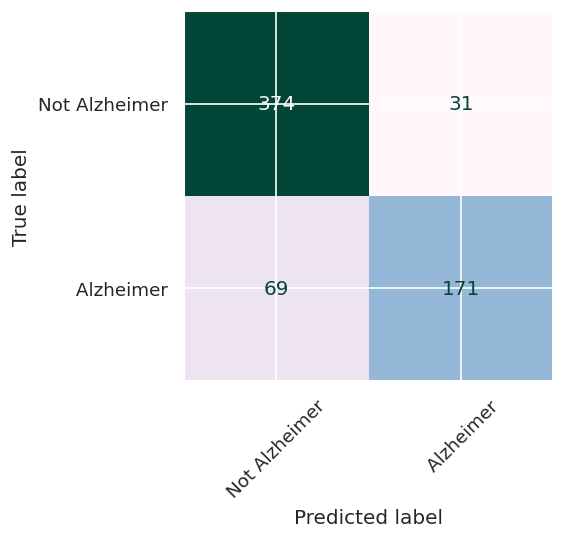

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer', ' Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       405
           1       0.85      0.71      0.77       240

    accuracy                           0.84       645
   macro avg       0.85      0.82      0.83       645
weighted avg       0.85      0.84      0.84       645



**Decission Tree**

In [ ]:
from sklearn import tree #Gọi mô hình
model_tree = tree.DecisionTreeClassifier(max_depth=5,random_state=1)  #Set max_depth bất kỳ
model_tree.fit(X_train, y_train) #Training mô hình

DecisionTreeClassifier(max_depth=5, random_state=1)

In [ ]:
#Đánh giá độ chính xác của mô hình
y_pred=model_tree.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred) #Độ chính xác của DT

0.9534883720930233

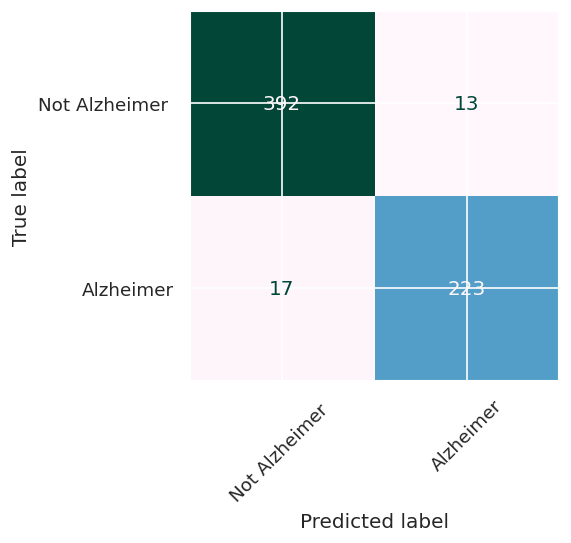

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer ', 'Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       405
           1       0.94      0.93      0.94       240

    accuracy                           0.95       645
   macro avg       0.95      0.95      0.95       645
weighted avg       0.95      0.95      0.95       645



In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
score_total=[]
for i in range(1,20):
  model_tree = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree.fit(X_train, y_train)
  y_pred=model_tree.predict(X_test)
  score_total.append(accuracy_score(y_test,y_pred))

In [ ]:
score_total

[0.6821705426356589,
 0.8015503875968992,
 0.9007751937984496,
 0.9472868217054263,
 0.9534883720930233,
 0.9395348837209302,
 0.9348837209302325,
 0.9333333333333333,
 0.931782945736434,
 0.9193798449612403,
 0.9255813953488372,
 0.9131782945736434,
 0.9209302325581395,
 0.9224806201550387,
 0.9178294573643411,
 0.9209302325581395,
 0.9131782945736434,
 0.9178294573643411,
 0.9178294573643411]

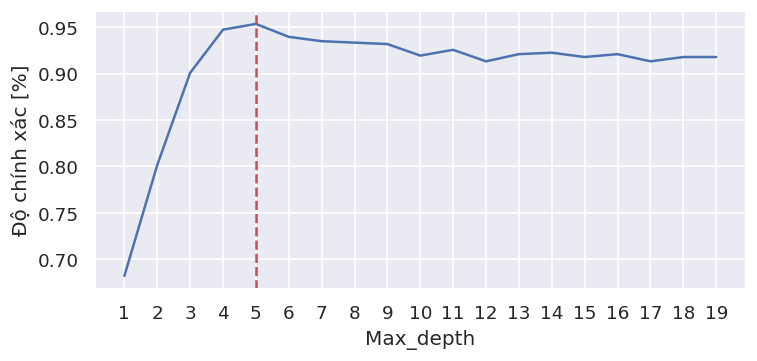

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 20), score_total)
plt.xticks(range(1, 20))
plt.axvline(x=5, color='r', linestyle='--')


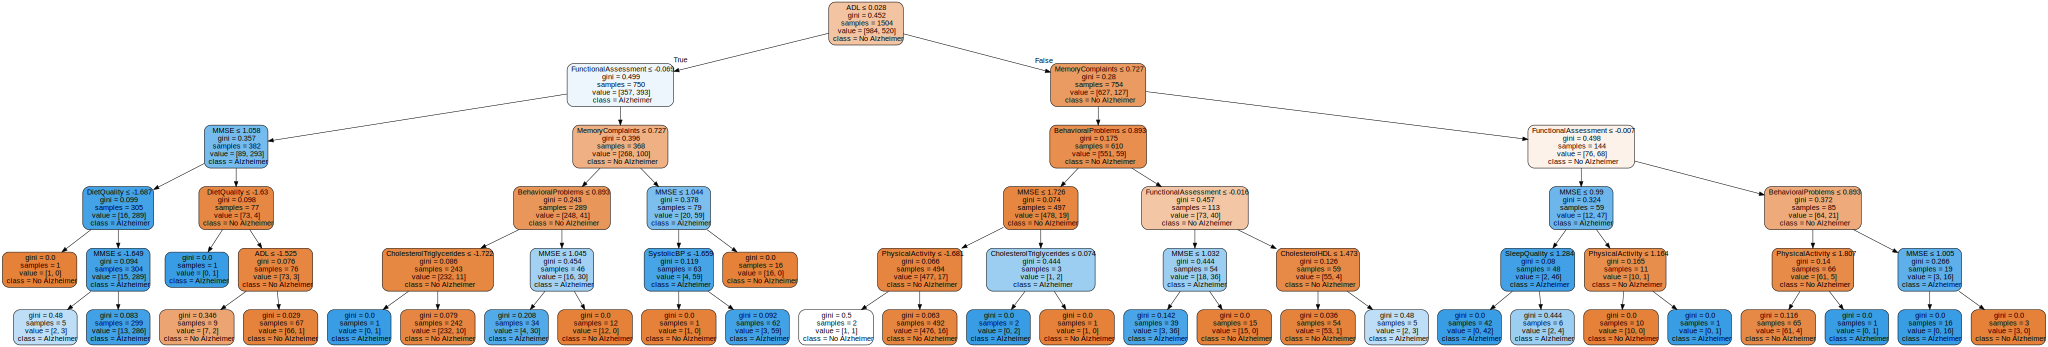

In [ ]:
# vẽ lại cây quyết định như sau
from sklearn import tree
model = tree.DecisionTreeClassifier(max_depth=5)
model = model.fit(X_train, y_train)#Tính toán/fit model
import graphviz #Thư viện để hiển thị hình ảnh
dot_data = tree.export_graphviz(model, out_file=None,feature_names=['Age','Gender','Ethnicity','EducationLevel','BMI','Smoking','AlcoholConsumption','PhysicalActivity','DietQuality','SleepQuality','FamilyHistoryAlzheimers','CardiovascularDisease','Diabetes','Depression','HeadInjury','Hypertension','SystolicBP','DiastolicBP','CholesterolTotal','CholesterolLDL','CholesterolHDL','CholesterolTriglycerides','MMSE','FunctionalAssessment','MemoryComplaints','BehavioralProblems','ADL','Confusion','Disorientation','PersonalityChanges','DifficultyCompletingTasks','Forgetfulness'],class_names=['No Alzheimer','Alzheimer'],filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

**Random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=30,max_features=10,criterion='entropy',random_state=1)
rf.fit(X_train, y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9705426356589147

In [ ]:
acc=[]
for i in range(1,30):
  rf = RandomForestClassifier(n_estimators=i,random_state=1)
  rf.fit(X_train, y_train)
  y_pred=rf.predict(X_test)
  acc.append(accuracy_score(y_test,y_pred))

In [ ]:
acc

[0.7209302325581395,
 0.7131782945736435,
 0.8015503875968992,
 0.7906976744186046,
 0.8418604651162791,
 0.8356589147286821,
 0.8837209302325582,
 0.8728682170542635,
 0.8992248062015504,
 0.8868217054263566,
 0.9038759689922481,
 0.8883720930232558,
 0.8976744186046511,
 0.8852713178294573,
 0.9007751937984496,
 0.8852713178294573,
 0.896124031007752,
 0.8914728682170543,
 0.9023255813953488,
 0.8976744186046511,
 0.9038759689922481,
 0.9007751937984496,
 0.9162790697674419,
 0.9131782945736434,
 0.9224806201550387,
 0.9162790697674419,
 0.924031007751938,
 0.9209302325581395,
 0.9286821705426357]

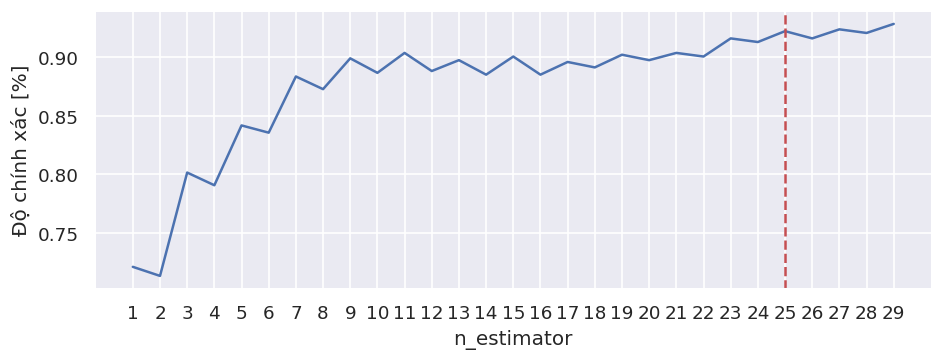

In [ ]:
#Vẽ hình thể hiện độ chính xác theo giá trị max_depth
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('n_estimator',fontsize=12)
plt.plot(range(1, 30), acc)
plt.xticks(range(1, 30))
plt.axvline(x=25, color='r', linestyle='--')
plt.grid('minor')

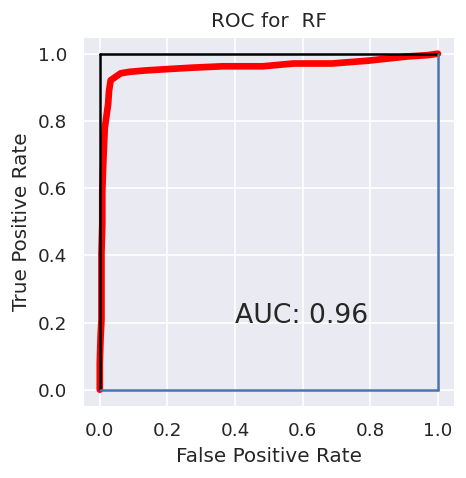

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
y_probabilities = rf.predict_proba(X_test)[:,1]
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test,y_probabilities)
plt.figure(figsize=(4,4))
plt.title('ROC for  RF')
plt.plot(false_positive_rate, true_positive_rate, linewidth=4, color='red')
#plt.plot([0,1],ls='--',linewidth=5)
plt.plot([0,0],[1,0],c='0')
plt.plot([1,1],c='0')
plt.plot([0,0],c='b')
plt.plot([1,1],[1,0],c='b')
plt.text(0.4,0.2,'AUC: {:.2f}'.format(roc_auc_score(y_test,y_probabilities)),size= 16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
#hyperparameter turning
#from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier()
from sklearn.model_selection import GridSearchCV
grid_space = {'max_depth':[3, 5, 10,15, 20, None],
              'n_estimators':[2,5,9,10,15 ,20, 30],
              'criterion':['gini','entropy']
              }
rf_grid = GridSearchCV(rf, param_grid=grid_space, scoring='recall')
model_grid = rf_grid.fit(X_train, y_train)

In [ ]:
model_grid.best_params_

{'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 20}

In [ ]:
y_pred=model_grid.predict(X_test)
accuracy_score(y_test,y_pred)

0.9333333333333333

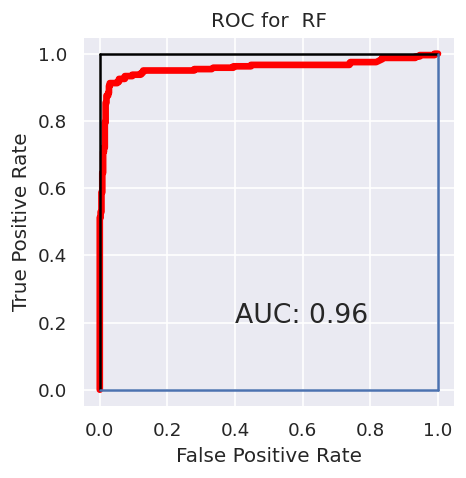

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
y_probabilities = model_grid.predict_proba(X_test)[:,1]
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test,y_probabilities)
plt.figure(figsize=(4,4))
plt.title('ROC for  RF')
plt.plot(false_positive_rate, true_positive_rate, linewidth=4, color='red')
#plt.plot([0,1],ls='--',linewidth=5)
plt.plot([0,0],[1,0],c='0')
plt.plot([1,1],c='0')
plt.plot([0,0],c='b')
plt.plot([1,1],[1,0],c='b')
plt.text(0.4,0.2,'AUC: {:.2f}'.format(roc_auc_score(y_test,y_probabilities)),size= 16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       405
           1       0.96      0.85      0.91       240

    accuracy                           0.93       645
   macro avg       0.94      0.92      0.93       645
weighted avg       0.94      0.93      0.93       645



Chọn decission tree

Max depth= 5

Acc = 95%

Recall Alzheimer = 93%

Tuy nhiên, không phải bệnh viện nào cũng có thể thu thập đầy đủ các thông tin như vậy. Chỉ có các bệnh viện tuyến trên và có nguồn lực về CSDL mới có thể thu thập đầy đủ các thông tin như trên. Vậy thì đối với các bệnh viện tuyến dưới, làm sao để các bác sĩ có thể thu thập đầy đủ thông tin phục vụ cho việc sử dụng mô hình để chẩn đoán nhằm đưa ra hướng điều trị kịp thời?
Vậy mô hình cần phải có sự tinh chỉnh để phù hợp hơn với các điều kiện trong thực tế.
Để giải quyết vấn đề này, em quyết định chia nhỏ dataset thành các nhóm nhỏ và thực hiện việc tinh chỉnh cho mô hình tối ưu ở trên sử dụng các nhóm nhỏ này. Điều này sẽ giúp các bác sĩ thu thập ít thông tin hơn và mô hình sẽ đưa ra tốc độ xử lý nhanh hơn do phải xử lý ít data hơn. Việc này sẽ hỗ trợ các bác sĩ tuyến dưới có thể áp dụng mô hình chẩn đoán trong việc đưa ra quyết định.
Các nhóm nhỏ em chia dựa vào tìm hiểu của bản thân cho những người bị Alzheimer, bao gồm: Demographic Group, Lifestyle Factor, Medical History, Clinic Measurement, Cognitive and Functional Assessments, và Symtoms.

**Demographic group**

In [ ]:
# for Demographic Details data group
#Age
#Gender
#Ethnicity
#EducationLevel


In [ ]:
#Data
X1=df[['Age','Gender','Ethnicity','EducationLevel']]
y1=df.Diagnosis
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1,test_size=0.3,random_state=0) # Chia dữ liệu với 30% số lượng là tets và 70% số lượng là training

In [ ]:
#scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X1_train)
X1_train = scaler.transform(X1_train)
X1_test = scaler.transform(X1_test)

In [ ]:
model_tree_demo = tree.DecisionTreeClassifier(max_depth=7,random_state=1)  #Set max_depth bất kỳ
model_tree_demo.fit(X1_train, y1_train) #Training mô hình

DecisionTreeClassifier(max_depth=7, random_state=1)

In [ ]:
#Đánh giá độ chính xác của mô hình
y1_pred=model_tree_demo.predict(X1_test)
from sklearn.metrics import accuracy_score
accuracy_score(y1_test,y1_pred) #Độ chính xác của DT

0.6217054263565891

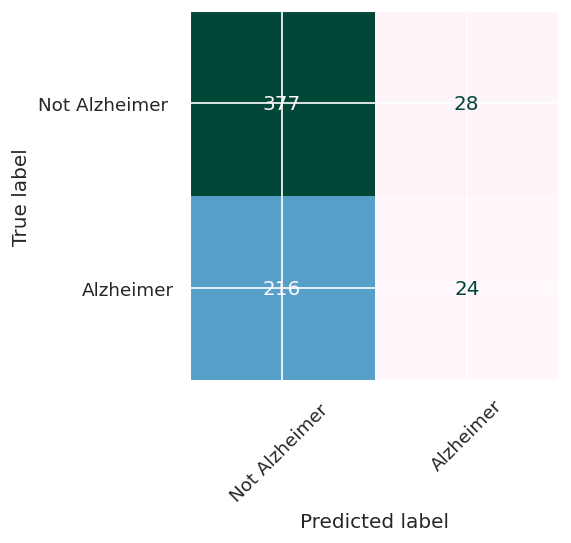

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y1_test, y1_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer ', 'Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y1_test, y1_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

           0       0.64      0.93      0.76       405
           1       0.46      0.10      0.16       240

    accuracy                           0.62       645
   macro avg       0.55      0.52      0.46       645
weighted avg       0.57      0.62      0.54       645



In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
score_total_1=[]
for i in range(1,20):
  model_tree_demo = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree_demo.fit(X1_train, y1_train)
  y1_pred = model_tree_demo.predict(X1_test)
  score_total_1.append(accuracy_score(y1_test,y1_pred))

In [ ]:
score_total_1

[0.627906976744186,
 0.627906976744186,
 0.6201550387596899,
 0.6186046511627907,
 0.6093023255813953,
 0.6077519379844961,
 0.6217054263565891,
 0.6108527131782946,
 0.6139534883720931,
 0.6093023255813953,
 0.6,
 0.5813953488372093,
 0.5829457364341085,
 0.586046511627907,
 0.5875968992248062,
 0.57984496124031,
 0.586046511627907,
 0.586046511627907,
 0.586046511627907]

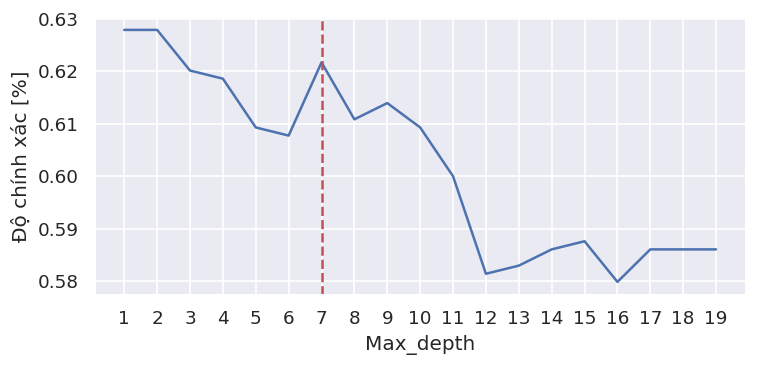

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 20), score_total_1)
plt.xticks(range(1, 20))
plt.axvline(x=7, color='r', linestyle='--')

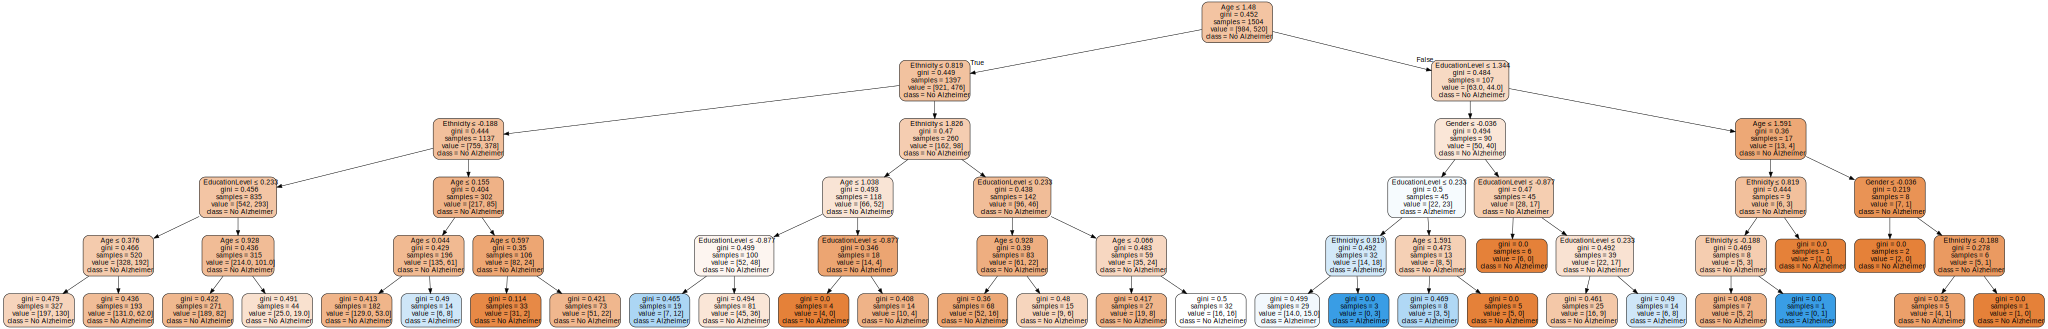

In [ ]:
# vẽ lại cây quyết định như sau
from sklearn import tree
model = tree.DecisionTreeClassifier(max_depth=5)
model = model.fit(X1_train, y1_train)#Tính toán/fit model
import graphviz #Thư viện để hiển thị hình ảnh
dot_data = tree.export_graphviz(model, out_file=None,feature_names=['Age','Gender','Ethnicity','EducationLevel'],class_names=['No Alzheimer','Alzheimer'],filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

**Lifestyle Factor**

In [ ]:
# for Lifestyle factor data group
#BMI
#Smoking
#AlcoholConsumption
#PhysicalActivity
#DietQuality
#SleepQuality


In [ ]:
#Data
X2=df[['BMI','Smoking','AlcoholConsumption','PhysicalActivity','DietQuality','SleepQuality']]
y2=df.Diagnosis
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size=0.3,random_state=0) # Chia dữ liệu với 30% số lượng là tets và 70% số lượng là training

In [ ]:
#scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X2_train)
X2_train = scaler.transform(X2_train)
X2_test = scaler.transform(X2_test)

In [ ]:
model_tree_life = tree.DecisionTreeClassifier(max_depth=1,random_state=1)  #Set max_depth bất kỳ
model_tree_life.fit(X2_train, y2_train) #Training mô hình

DecisionTreeClassifier(max_depth=1, random_state=1)

In [ ]:
#Đánh giá độ chính xác của mô hình
y2_pred=model_tree_life.predict(X2_test)
from sklearn.metrics import accuracy_score
accuracy_score(y2_test,y2_pred) #Độ chính xác của DT

0.627906976744186

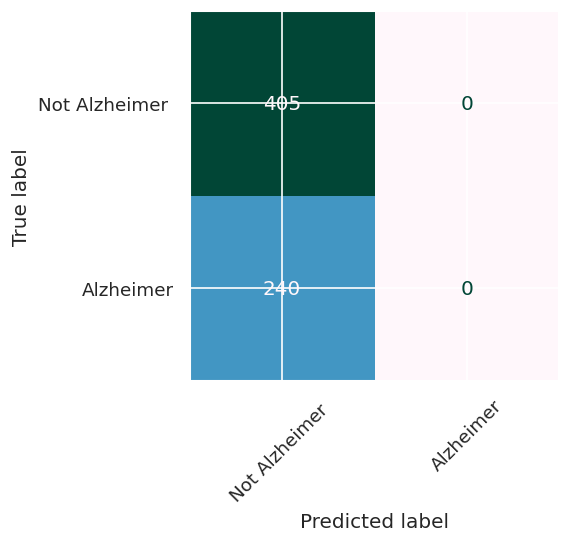

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y2_test, y2_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer ', 'Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y2_test, y2_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       405
           1       0.00      0.00      0.00       240

    accuracy                           0.63       645
   macro avg       0.31      0.50      0.39       645
weighted avg       0.39      0.63      0.48       645



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
score_total_2=[]
for i in range(1,20):
  model_tree_life = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree_life.fit(X2_train, y2_train)
  y2_pred = model_tree_life.predict(X2_test)
  score_total_2.append(accuracy_score(y2_test,y2_pred))

In [ ]:
score_total_2

[0.627906976744186,
 0.6217054263565891,
 0.6201550387596899,
 0.6186046511627907,
 0.6186046511627907,
 0.6217054263565891,
 0.5984496124031008,
 0.5643410852713179,
 0.5674418604651162,
 0.5503875968992248,
 0.5565891472868217,
 0.5410852713178295,
 0.5271317829457365,
 0.5286821705426357,
 0.5007751937984496,
 0.5116279069767442,
 0.517829457364341,
 0.5100775193798449,
 0.5147286821705427]

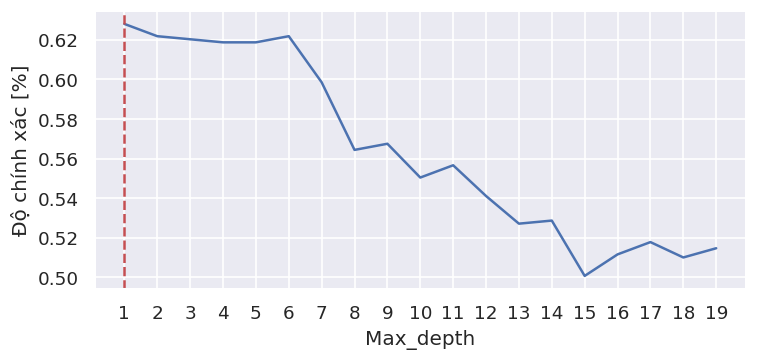

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 20), score_total_2)
plt.xticks(range(1, 20))
plt.axvline(x=1, color='r', linestyle='--')

**Medical history**

In [ ]:
# data for Medical History


In [ ]:
#Data
X3=df[['FamilyHistoryAlzheimers','CardiovascularDisease','Diabetes','Depression','HeadInjury','Hypertension']]
y3=df.Diagnosis
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3,test_size=0.3,random_state=0) # Chia dữ liệu với 30% số lượng là tets và 70% số lượng là training

In [ ]:
#scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X3_train)
X3_train = scaler.transform(X3_train)
X3_test = scaler.transform(X3_test)

In [ ]:
model_tree_medi = tree.DecisionTreeClassifier(max_depth=1,random_state=1)  #Set max_depth bất kỳ
model_tree_medi.fit(X3_train, y3_train) #Training mô hình

DecisionTreeClassifier(max_depth=1, random_state=1)

In [ ]:
#Đánh giá độ chính xác của mô hình
y3_pred=model_tree_medi.predict(X3_test)
from sklearn.metrics import accuracy_score
accuracy_score(y3_test,y3_pred) #Độ chính xác của DT

0.627906976744186

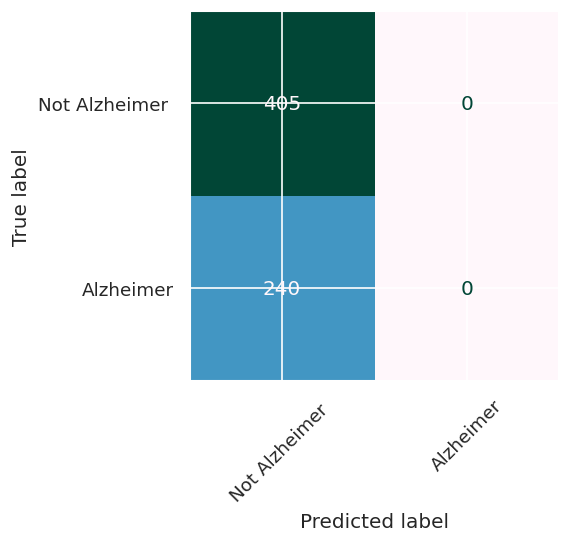

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y3_test, y3_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer ', 'Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y3_test, y3_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y3_test, y3_pred))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       405
           1       0.00      0.00      0.00       240

    accuracy                           0.63       645
   macro avg       0.31      0.50      0.39       645
weighted avg       0.39      0.63      0.48       645



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
score_total_3=[]
for i in range(1,20):
  model_tree_medi = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree_medi.fit(X3_train, y3_train)
  y3_pred = model_tree_medi.predict(X3_test)
  score_total_3.append(accuracy_score(y3_test,y3_pred))

In [ ]:
score_total_3

[0.627906976744186,
 0.627906976744186,
 0.627906976744186,
 0.6186046511627907,
 0.6232558139534884,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869]

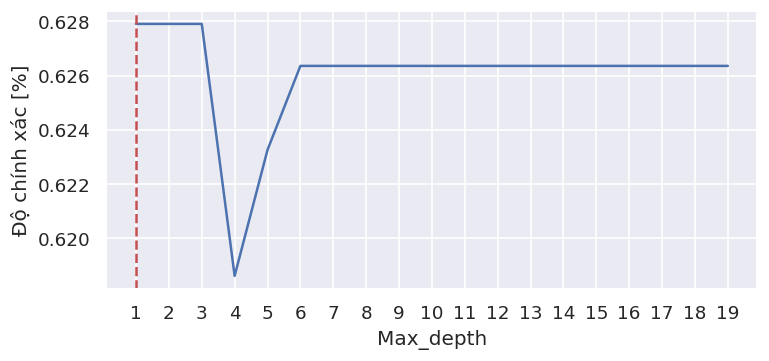

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 20), score_total_3)
plt.xticks(range(1, 20))
plt.axvline(x=1, color='r', linestyle='--')

**Clinic Mesurements**

In [ ]:
#Data
X4=df[['SystolicBP','DiastolicBP','CholesterolTotal','CholesterolLDL','CholesterolHDL','CholesterolTriglycerides']]
y4=df.Diagnosis
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X4_train, X4_test, y4_train, y4_test = train_test_split(X4,y4,test_size=0.3,random_state=0) # Chia dữ liệu với 30% số lượng là tets và 70% số lượng là training

In [ ]:
#scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X4_train)
X4_train = scaler.transform(X4_train)
X4_test = scaler.transform(X4_test)

In [ ]:
model_tree_clinic = tree.DecisionTreeClassifier(max_depth=1,random_state=1)  #Set max_depth bất kỳ
model_tree_clinic.fit(X4_train, y4_train) #Training mô hình

DecisionTreeClassifier(max_depth=1, random_state=1)

In [ ]:
#Đánh giá độ chính xác của mô hình
y4_pred=model_tree_clinic.predict(X4_test)
from sklearn.metrics import accuracy_score
accuracy_score(y4_test,y4_pred) #Độ chính xác của DT

0.627906976744186

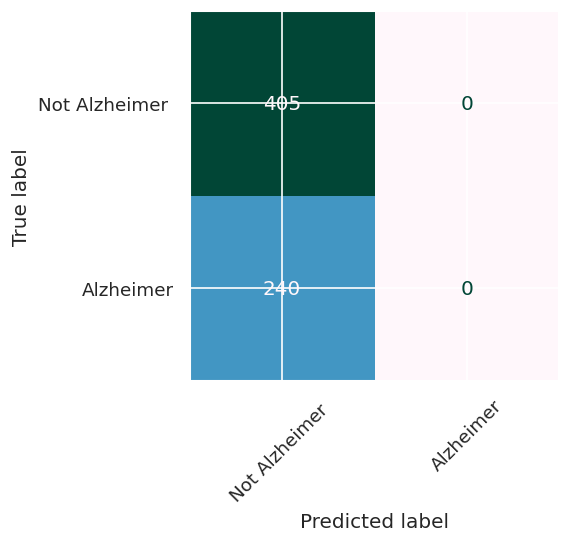

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y4_test, y4_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer ', 'Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y4_test, y4_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y4_test, y4_pred))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       405
           1       0.00      0.00      0.00       240

    accuracy                           0.63       645
   macro avg       0.31      0.50      0.39       645
weighted avg       0.39      0.63      0.48       645



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
score_total_4=[]
for i in range(1,20):
  model_tree_clinic = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree_clinic.fit(X4_train, y4_train)
  y4_pred = model_tree_clinic.predict(X4_test)
  score_total_4.append(accuracy_score(y4_test,y4_pred))

In [ ]:
score_total_4

[0.627906976744186,
 0.627906976744186,
 0.6248062015503876,
 0.6062015503875969,
 0.6062015503875969,
 0.5813953488372093,
 0.586046511627907,
 0.5658914728682171,
 0.5705426356589147,
 0.5674418604651162,
 0.5271317829457365,
 0.5441860465116279,
 0.5410852713178295,
 0.517829457364341,
 0.5131782945736434,
 0.517829457364341,
 0.49767441860465117,
 0.5147286821705427,
 0.5255813953488372]

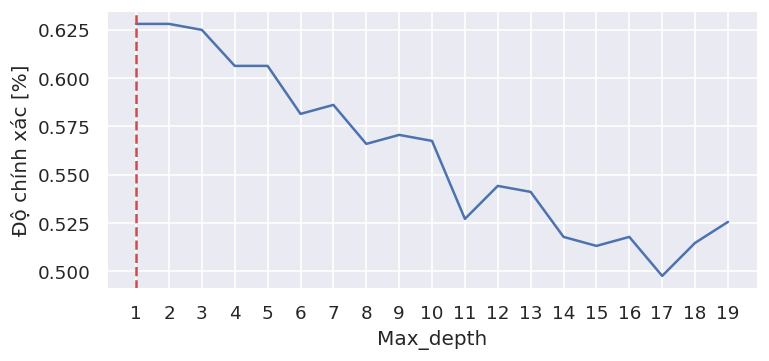

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 20), score_total_4)
plt.xticks(range(1, 20))
plt.axvline(x=1, color='r', linestyle='--')

**Cognitive and Functional Assessments**

In [ ]:
#Data
X5=df[['MMSE','FunctionalAssessment','MemoryComplaints','BehavioralProblems','ADL']]
y5=df.Diagnosis
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X5_train, X5_test, y5_train, y5_test = train_test_split(X5,y5,test_size=0.3,random_state=0) # Chia dữ liệu với 30% số lượng là tets và 70% số lượng là training

In [ ]:
#scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X5_train)
X5_train = scaler.transform(X5_train)
X5_test = scaler.transform(X5_test)

In [ ]:
model_tree_cog = tree.DecisionTreeClassifier(max_depth=5,random_state=1)  #Set max_depth bất kỳ
model_tree_cog.fit(X5_train, y5_train) #Training mô hình

DecisionTreeClassifier(max_depth=5, random_state=1)

In [ ]:
#Đánh giá độ chính xác của mô hình
y5_pred=model_tree_cog.predict(X5_test)
from sklearn.metrics import accuracy_score
accuracy_score(y5_test,y5_pred) #Độ chính xác của DT

0.9612403100775194

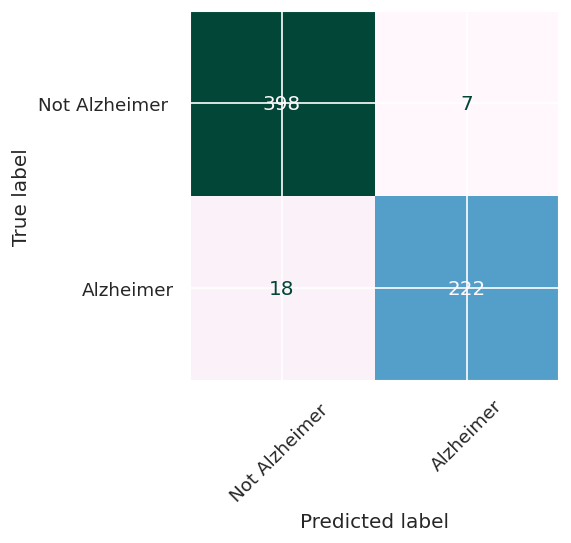

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y5_test, y5_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer ', 'Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y5_test, y5_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y5_test, y5_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       405
           1       0.97      0.93      0.95       240

    accuracy                           0.96       645
   macro avg       0.96      0.95      0.96       645
weighted avg       0.96      0.96      0.96       645



In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
score_total_5=[]
for i in range(1,20):
  model_tree_cog = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree_cog.fit(X5_train, y5_train)
  y5_pred = model_tree_cog.predict(X5_test)
  score_total_5.append(accuracy_score(y5_test,y5_pred))

In [ ]:
score_total_5

[0.6821705426356589,
 0.8015503875968992,
 0.9007751937984496,
 0.9488372093023256,
 0.9612403100775194,
 0.9550387596899225,
 0.9488372093023256,
 0.937984496124031,
 0.9333333333333333,
 0.9286821705426357,
 0.9286821705426357,
 0.924031007751938,
 0.931782945736434,
 0.9178294573643411,
 0.9147286821705426,
 0.9131782945736434,
 0.9100775193798449,
 0.9085271317829458,
 0.9085271317829458]

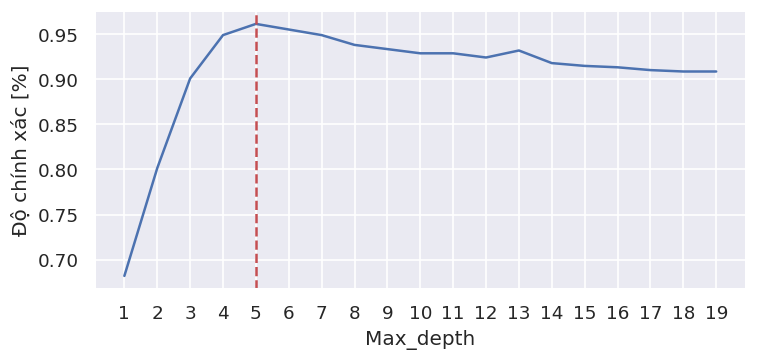

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 20), score_total_5)
plt.xticks(range(1, 20))
plt.axvline(x=5, color='r', linestyle='--')

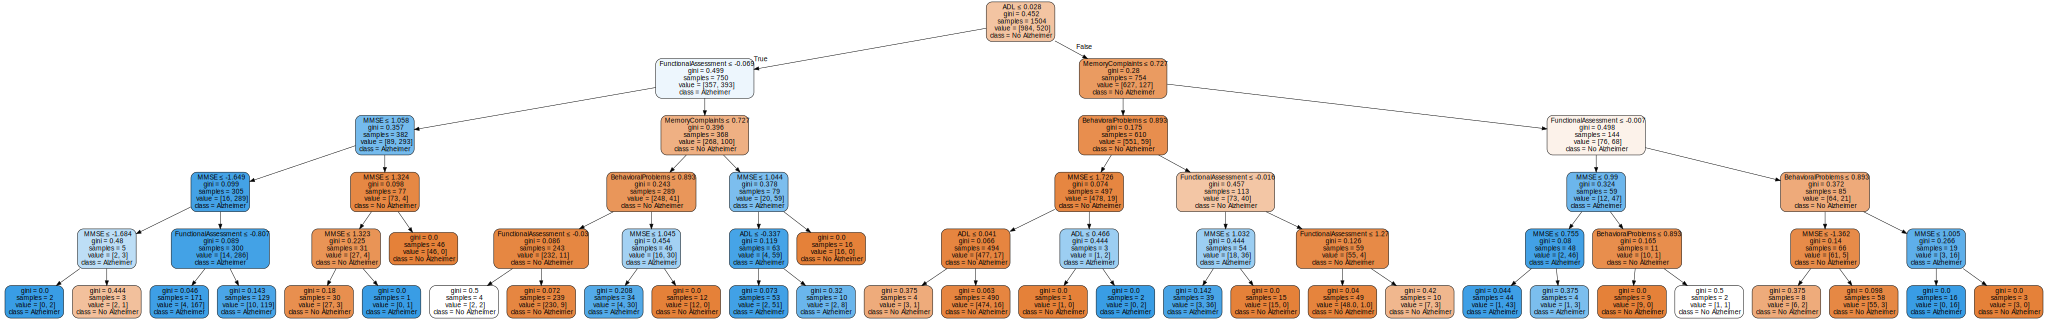

In [ ]:
# vẽ lại cây quyết định như sau
from sklearn import tree
model = tree.DecisionTreeClassifier(max_depth=5)
model = model.fit(X5_train, y5_train)#Tính toán/fit model
import graphviz #Thư viện để hiển thị hình ảnh
dot_data = tree.export_graphviz(model, out_file=None,feature_names=['MMSE','FunctionalAssessment','MemoryComplaints','BehavioralProblems','ADL'],class_names=['No Alzheimer','Alzheimer'],filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

**Symtoms**

In [ ]:
#Data
X6=df[['Confusion','Disorientation','PersonalityChanges','DifficultyCompletingTasks','Forgetfulness']]
y6=df.Diagnosis
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X6_train, X6_test, y6_train, y6_test = train_test_split(X6,y6,test_size=0.3,random_state=0) # Chia dữ liệu với 30% số lượng là tets và 70% số lượng là training

In [ ]:
#scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X6_train)
X6_train = scaler.transform(X6_train)
X6_test = scaler.transform(X6_test)

In [ ]:
model_tree_sym = tree.DecisionTreeClassifier(max_depth=5,random_state=1)  #Set max_depth bất kỳ
model_tree_sym.fit(X6_train, y6_train) #Training mô hình

DecisionTreeClassifier(max_depth=5, random_state=1)

In [ ]:
#Đánh giá độ chính xác của mô hình
y6_pred=model_tree_sym.predict(X6_test)
from sklearn.metrics import accuracy_score
accuracy_score(y6_test,y6_pred) #Độ chính xác của DT

0.6263565891472869

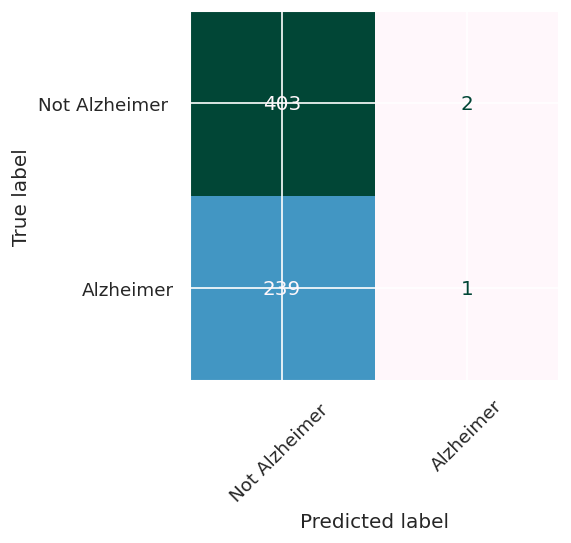

In [ ]:
#Đánh giá mô hình bằng confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(y6_test, y6_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
labels = ['Not Alzheimer ', 'Alzheimer']#Tên class
ConfusionMatrixDisplay.from_predictions(
    y6_test, y6_pred, display_labels=labels, xticks_rotation=45,
    ax=ax, colorbar=False, cmap="PuBuGn")

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y6_test, y6_pred))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       405
           1       0.33      0.00      0.01       240

    accuracy                           0.63       645
   macro avg       0.48      0.50      0.39       645
weighted avg       0.52      0.63      0.49       645



In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
score_total_6=[]
for i in range(1,20):
  model_tree_sym = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree_sym.fit(X6_train, y6_train)
  y6_pred = model_tree_sym.predict(X6_test)
  score_total_6.append(accuracy_score(y6_test,y6_pred))

In [ ]:
score_total_6

[0.627906976744186,
 0.627906976744186,
 0.627906976744186,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869,
 0.6263565891472869]

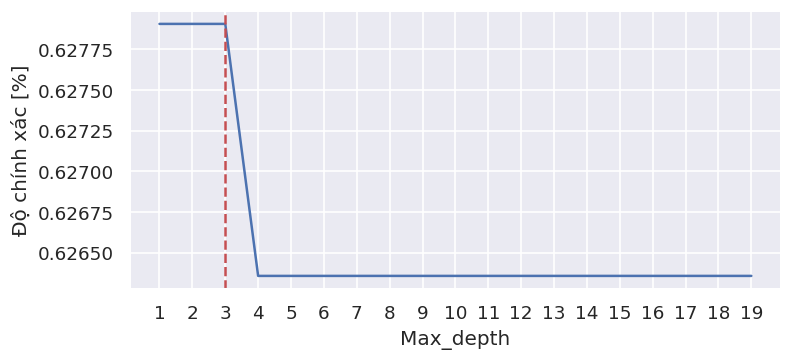

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('Độ chính xác [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 20), score_total_6)
plt.xticks(range(1, 20))
plt.axvline(x=3, color='r', linestyle='--')

In [ ]:
# Lưu lại mô hình
import pickle

In [ ]:
with open('model_tree_cog.pkl', 'wb') as f:
    pickle.dump(model_tree_cog, f)

In [ ]:
# gọi mô hình ra bằng Google Drive
from google.colab import drive
drive.mount('/content/drive')


ValueError: mount failed

In [ ]:
model_path = '/content/drive/MyDrive/Luan's personal project/5.model_tree_cog.pkl'


In [ ]:
with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)